/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_24955/3351478002.py:203: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/fionachow/opt/anaconda3/envs/rl/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


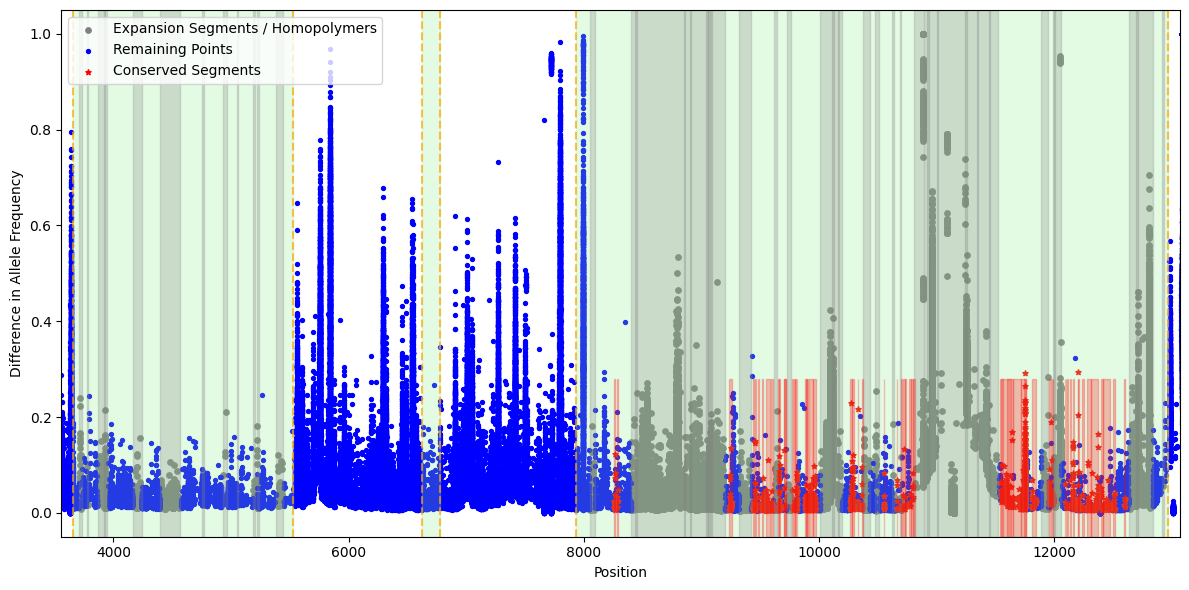

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
import os
import glob
import io

# 28S ExpansionSegments
data = np.array([
    ['ESL5', 'ESL7', 'ESL9', 'ESL10', 'ESL12', 'ESL15', 'ESL19', 'ESL20', 'ESL24', 'ESL26', 'ESL27', 'ESL30', 'ESL31', 'ESL39', 'ESL41'],
    [114, 465, 1384, 1682, 1793, 2075, 2439, 2538, 2685, 2751, 2875, 3955, 4057, 4698, 4983],
    [156, 1265, 1487, 1711, 1829, 2256, 2494, 2575, 2705, 2764, 3586, 4013, 4124, 4905, 4996]
])

df1 = pd.DataFrame(data.T, columns=['Segment', 'Start', 'End'])
df1['Start'] = pd.to_numeric(df1['Start']) + 7935
df1['End'] = pd.to_numeric(df1['End']) + 7935
# print(df1)

# 18S ExpansionSegments
data = np.array([
    ['ESS1', 'ESS2', 'ESS3', 'ESS4', 'ESS6', 'ESS7', 'ESS8', 'ESS9', 'ESS10', 'ESS11', 'ESS12'],
    [53, 116, 208, 512, 737, 1097, 1272, 1398, 1533, 1563, 1726],
    [73, 130, 291, 583, 911, 1114, 1305, 1403, 1551, 1581, 1789]
])

df2 = pd.DataFrame(data.T, columns=['Segment', 'Start', 'End'])
df2['Start'] = pd.to_numeric(df2['Start']) + 3657
df2['End'] = pd.to_numeric(df2['End']) + 3657
# print(df2)

# Reading other necessary data
df3 = pd.read_csv(r'/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/homopolymers.csv')
# print(df3)

df4 = pd.read_csv(r'/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/Copy of conserve - Sheet1.csv')

def read_txt2(path):
    df = pd.read_csv(path)
    fxhold = df['POS'].tolist()
    refhold = df['new_ref'].tolist()
    althold = df['ALT_new'].tolist()
    fhold = df['AF_new'].tolist()
    return fhold, fxhold, refhold, althold

def get_rRNA_bounds(gb_file_path):
    gb_file = open(gb_file_path)
    pattern_1 = r'^\s+rRNA'
    pattern_2 = r'\d+'
    points = []
    for line in gb_file:
        if re.search(pattern_1, line):
            send = re.findall(pattern_2, line)
            points.append([int(send[0]), int(send[1])])
    return points

# File paths
gb_file_path = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/U13369.1_Human_rDNA_repeat_unit.gb'
vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/src_outputs/new_vcf/'

# Verify if vcf_directory is indeed a directory and list files
if os.path.isdir(vcf_directory):
    vcf_files = [os.path.join(vcf_directory, file) for file in os.listdir(vcf_directory)]
else:
    raise ValueError(f"{vcf_directory} is not a valid directory")

# print(f"Found VCF files: {vcf_files}")

# Get rRNA positions
rRNA_positions = get_rRNA_bounds(gb_file_path)
zoomed_range = [rRNA_positions[0][0] - 100, rRNA_positions[-1][-1] + 100]

expansion_positions1 = []
for row in df1.iterrows():
    hold = []
    hold.append(row[1]['Start'])
    hold.append(row[1]['End'])
    expansion_positions1.append(hold)
# print(expansion_positions1)

expansion_positions2 = []
for row in df2.iterrows():
    hold = []
    hold.append(row[1]['Start'])
    hold.append(row[1]['End'])
    expansion_positions2.append(hold)
# print(expansion_positions2)

hmplr_pos = []
for row in df3.iterrows():
    hold = []
    hold.append(row[1]['Start'])
    hold.append(row[1]['End'])
    hmplr_pos.append(hold)
# print(hmplr_pos)

csvd_pos = []
for row in df4.iterrows():
    hold = []
    hold.append(row[1]['Start'])
    hold.append(row[1]['End'])
    csvd_pos.append(hold)
# print(csvd_pos)

# Initialize lists to store scatter data
grey_x, grey_y, blue_x, blue_y, red_x, red_y = [], [], [], [], [], []

# Plotting section
plt.figure(figsize=(12, 6))
for file in vcf_files:
    # print(f"Processing file: {file}")
    hold, xhold, rh, ah = read_txt2(file)
    # print(f"Data loaded: {len(hold)} records")
    grey_x_temp = []
    grey_y_temp = []
    blue_x_temp = []
    blue_y_temp = []
    red_x_temp = []
    red_y_temp = []
    data = pd.DataFrame({'x': xhold, 'y': hold})
    
    # print(f"Initial data points: {len(data)}")

    # Processing 28S segments
    for _, segment in df1.iterrows():
        start, end = segment['Start'], segment['End']
        mask = (data['x'] >= start) & (data['x'] <= end)
        selected_data = data[mask]
        grey_x_temp.extend(selected_data['x'].tolist())
        grey_y_temp.extend(selected_data['y'].tolist())
        data = data[~mask]
    
    # Processing 18S segments
    for _, segment in df2.iterrows():
        start, end = segment['Start'], segment['End']
        mask2 = (data['x'] >= start) & (data['x'] <= end)
        selected_data2 = data[mask2]
        grey_x_temp.extend(selected_data2['x'].tolist())
        grey_y_temp.extend(selected_data2['y'].tolist())
        data = data[~mask2]
    
    # Processing homopolymer segments
    for _, segment in df3.iterrows():
        start, end = segment['Start'], segment['End']
        mask3 = (data['x'] >= start) & (data['x'] <= end)
        selected_data3 = data[mask3]
        grey_x_temp.extend(selected_data3['x'].tolist())
        grey_y_temp.extend(selected_data3['y'].tolist())
        data = data[~mask3]
    
    # Processing conserved segments
    for _, segment in df4.iterrows():
        start, end = segment['Start'], segment['End']
        mask4 = (data['x'] >= start) & (data['x'] <= end)
        selected_data4 = data[mask4]
        red_x_temp.extend(selected_data4['x'].tolist())
        red_y_temp.extend(selected_data4['y'].tolist())
        data = data[~mask4]

    # Remaining points are blue points
    blue_x_temp.extend(data['x'].tolist())
    blue_y_temp.extend(data['y'].tolist())

    grey_x.extend(grey_x_temp)
    grey_y.extend(grey_y_temp)
    blue_x.extend(blue_x_temp)
    blue_y.extend(blue_y_temp)
    red_x.extend(red_x_temp)
    red_y.extend(red_y_temp)

# print(f"Grey points (grey_x, grey_y): {len(grey_x)}, {len(grey_y)}")
# print(f"Blue points (blue_x, blue_y): {len(blue_x)}, {len(blue_y)}")
# print(f"Red star points (red_x, red_y): {len(red_x)}, {len(red_y)}")

# Plot grey points, blue points, and red stars
plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments / Homopolymers')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')

# Add vertical lines and shaded regions
for start, end in rRNA_positions:
    plt.axvline(x=start, color='orange', linestyle='--', alpha=0.7)
    plt.axvline(x=end, color='orange', linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions2:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in hmplr_pos:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red')

plt.xlabel('Position')
plt.ylabel('Difference in Allele Frequency')
plt.xlim(zoomed_range)
plt.legend()
plt.tight_layout()
plt.show()


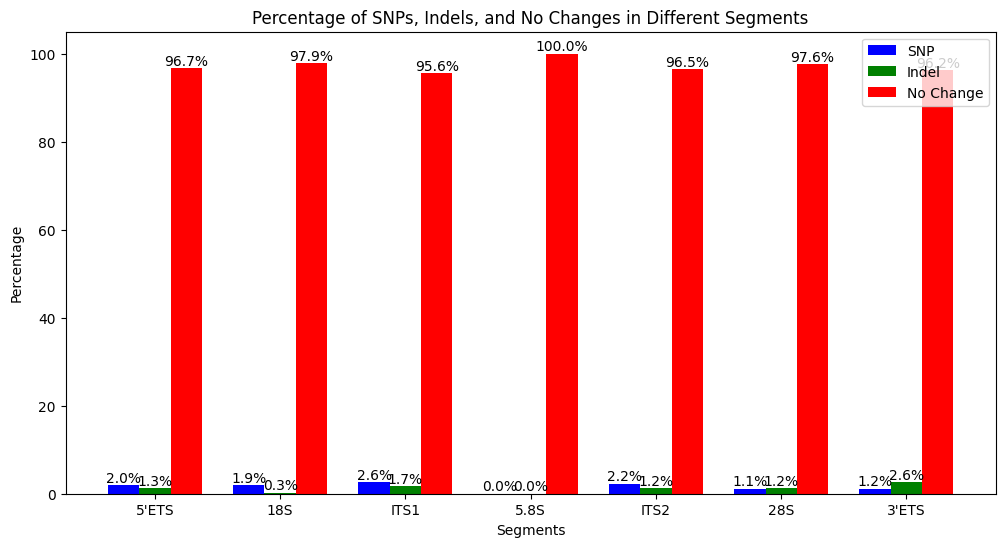

Overall SNP Percentage: 1.67%
Overall Indel Percentage: 1.17%
Overall No Change Percentage: 97.16%


In [39]:
vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Spring 2024/Research Fair/Hochwagen/Individual Data/ERR3240115/'

all_positions = [
    [1, 3656, "5'ETS"],
    [3657, 5527, '18S'],
    [5528, 6622, 'ITS1'],
    [6623, 6779, '5.8S'],
    [6780, 7934, 'ITS2'],
    [7935, 12969, '28S'],
    [12970, 13314, "3'ETS"]
]

# Initialize dictionaries to store counts of unique SNPs, indels, and no changes
position_data = {i: {'snp': set(), 'indel': set(), 'no_change': 0} for i in range(1, 13315)}

# Function to parse VCF files and classify SNPs and indels
def parse_vcf(file):
    vcf_df = pd.read_csv(file, comment='#', delimiter='\t', header=None,
                         names=['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO'])
    for _, row in vcf_df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']
        if len(ref) == len(alt):
            variation = f"{ref}_{alt}"
            position_data[pos]['snp'].add(variation)
        else:
            variation = f"{ref}_{alt}"
            position_data[pos]['indel'].add(variation)
    
    # Track positions with no changes
    all_positions_set = set(range(1, 13315))
    vcf_positions_set = set(vcf_df['POS'].tolist())
    no_change_positions = all_positions_set - vcf_positions_set
    for pos in no_change_positions:
        position_data[pos]['no_change'] = 1

vcf_files = glob.glob(vcf_directory + '*.vcf')
for vcf_file in vcf_files:
    parse_vcf(vcf_file)

# Prepare data for each segment
segment_data = {label: {'snp': 0, 'indel': 0, 'no_change': 0} for _, _, label in all_positions}

# Count occurrences for each segment
for pos in range(1, 13315):
    for start, end, label in all_positions:
        if start <= pos <= end:
            segment_data[label]['snp'] += len(position_data[pos]['snp'])
            segment_data[label]['indel'] += len(position_data[pos]['indel'])
            segment_data[label]['no_change'] += position_data[pos]['no_change']

# Calculate percentages for each segment
segment_percentages = {}
for label in segment_data:
    total_count = (segment_data[label]['snp'] + 
                   segment_data[label]['indel'] + 
                   segment_data[label]['no_change'])
    if total_count > 0:
        snp_percentage = (segment_data[label]['snp'] / total_count) * 100
        indel_percentage = (segment_data[label]['indel'] / total_count) * 100
        no_change_percentage = (segment_data[label]['no_change'] / total_count) * 100
    else:
        snp_percentage = indel_percentage = no_change_percentage = 0
    
    segment_percentages[label] = {
        'snp': snp_percentage,
        'indel': indel_percentage,
        'no_change': no_change_percentage
    }

# Prepare data for histogram
segments = list(segment_percentages.keys())
snp_percentages = [segment_percentages[seg]['snp'] for seg in segments]
indel_percentages = [segment_percentages[seg]['indel'] for seg in segments]
no_change_percentages = [segment_percentages[seg]['no_change'] for seg in segments]

# Plotting the histogram
bar_width = 0.25
x = range(len(segments))

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x, snp_percentages, color='b', width=bar_width, label='SNP')
bars2 = plt.bar([p + bar_width for p in x], indel_percentages, color='g', width=bar_width, label='Indel')
bars3 = plt.bar([p + bar_width * 2 for p in x], no_change_percentages, color='r', width=bar_width, label='No Change')

plt.xlabel('Segments')
plt.ylabel('Percentage')
plt.title('Percentage of SNPs, Indels, and No Changes in Different Segments')
plt.xticks([p + bar_width for p in x], segments)

plt.legend()

# Adding percentage labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.1f}%', ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.show()

# Calculate overall percentages across the entire dataset
total_snp = sum(len(position_data[pos]['snp']) for pos in range(1, 13315))
total_indel = sum(len(position_data[pos]['indel']) for pos in range(1, 13315))
total_no_change = sum(position_data[pos]['no_change'] for pos in range(1, 13315))
total_positions = total_snp + total_indel + total_no_change

overall_snp_percentage = (total_snp / total_positions) * 100
overall_indel_percentage = (total_indel / total_positions) * 100
overall_no_change_percentage = (total_no_change / total_positions) * 100

# Print overall percentages
print(f"Overall SNP Percentage: {overall_snp_percentage:.2f}%")
print(f"Overall Indel Percentage: {overall_indel_percentage:.2f}%")
print(f"Overall No Change Percentage: {overall_no_change_percentage:.2f}%")

In [40]:
total_positions

13346

In [41]:
segment_data

{"5'ETS": {'snp': 73, 'indel': 46, 'no_change': 3542},
 '18S': {'snp': 35, 'indel': 5, 'no_change': 1831},
 'ITS1': {'snp': 29, 'indel': 19, 'no_change': 1053},
 '5.8S': {'snp': 0, 'indel': 0, 'no_change': 157},
 'ITS2': {'snp': 26, 'indel': 14, 'no_change': 1116},
 '28S': {'snp': 56, 'indel': 63, 'no_change': 4936},
 "3'ETS": {'snp': 4, 'indel': 9, 'no_change': 332}}

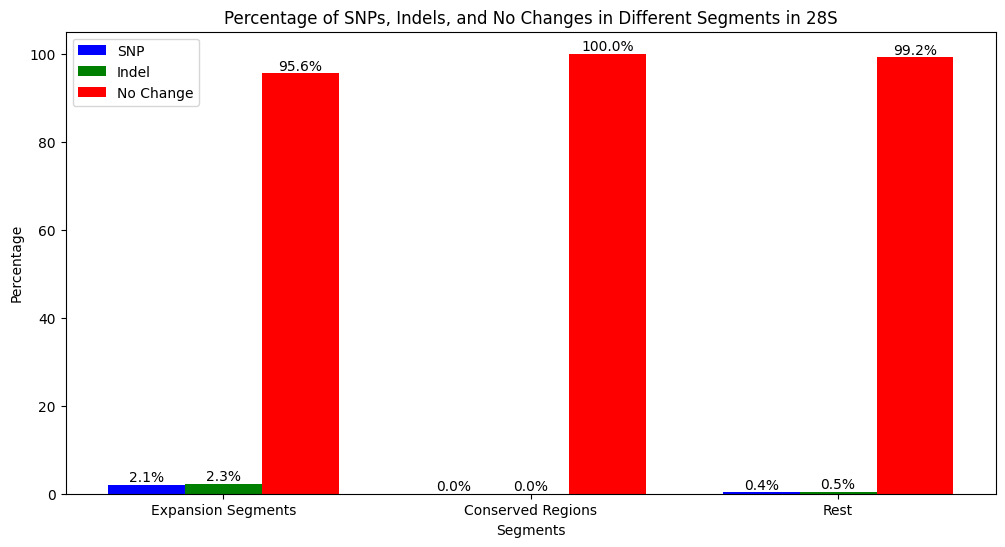

In [118]:
#28S only

exp_cor = []
exp_cor.extend(expansion_positions1)
exp_cor.extend(expansion_positions2)


# Prepare data for each segment category
segment_data = {
    'Expansion Segments': {'snp': 0, 'indel': 0, 'no_change': 0},
    'Conserved Regions': {'snp': 0, 'indel': 0, 'no_change': 0},
    'Rest': {'snp': 0, 'indel': 0, 'no_change': 0}
}

# Loop through each position in the range 7935,12970
for pos in range(7935, 12970):
    counted = False
    
    # Check for expansion segments
    for start, end in exp_cor:
        if start <= pos <= end:
            segment_data['Expansion Segments']['snp'] += len(position_data[pos]['snp'])
            segment_data['Expansion Segments']['indel'] += len(position_data[pos]['indel'])
            segment_data['Expansion Segments']['no_change'] += position_data[pos]['no_change']
            counted = True  # Mark position as counted
            break
    
    # Check for conserved regions if not already counted
    if not counted:
        for start, end in csvd_pos:
            if start <= pos <= end:
                segment_data['Conserved Regions']['snp'] += len(position_data[pos]['snp'])
                segment_data['Conserved Regions']['indel'] += len(position_data[pos]['indel'])
                segment_data['Conserved Regions']['no_change'] += position_data[pos]['no_change']
                counted = True  
                break
    
    # Check for rest if not already counted
    if not counted:
        for start, end in rRNA_positions:
            if start <= pos <= end:
                segment_data['Rest']['snp'] += len(position_data[pos]['snp'])
                segment_data['Rest']['indel'] += len(position_data[pos]['indel'])
                segment_data['Rest']['no_change'] += position_data[pos]['no_change']
                counted = True  
                break

# Calculate percentages for each category
segment_percentages = {}
for label in segment_data:
    total_count = (segment_data[label]['snp'] + 
                   segment_data[label]['indel'] + 
                   segment_data[label]['no_change'])
    if total_count > 0:
        snp_percentage = (segment_data[label]['snp'] / total_count) * 100
        indel_percentage = (segment_data[label]['indel'] / total_count) * 100
        no_change_percentage = (segment_data[label]['no_change'] / total_count) * 100
    else:
        snp_percentage = indel_percentage = no_change_percentage = 0
    
    segment_percentages[label] = {
        'snp': snp_percentage,
        'indel': indel_percentage,
        'no_change': no_change_percentage
    }

# Prepare data for histogram
categories = list(segment_percentages.keys())
snp_percentages = [segment_percentages[cat]['snp'] for cat in categories]
indel_percentages = [segment_percentages[cat]['indel'] for cat in categories]
no_change_percentages = [segment_percentages[cat]['no_change'] for cat in categories]

# Plotting the histogram
bar_width = 0.25
x = range(len(categories))

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x, snp_percentages, color='b', width=bar_width, label='SNP')
bars2 = plt.bar([p + bar_width for p in x], indel_percentages, color='g', width=bar_width, label='Indel')
bars3 = plt.bar([p + bar_width * 2 for p in x], no_change_percentages, color='r', width=bar_width, label='No Change')

plt.xlabel('Segments')
plt.ylabel('Percentage')
plt.title('Percentage of SNPs, Indels, and No Changes in Different Segments in 28S')
plt.xticks([p + bar_width for p in x], categories)

plt.legend()

# Adding percentage labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.1f}%', ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.show()



In [119]:
segment_data

{'Expansion Segments': {'snp': 50, 'indel': 55, 'no_change': 2301},
 'Conserved Regions': {'snp': 0, 'indel': 0, 'no_change': 963},
 'Rest': {'snp': 6, 'indel': 8, 'no_change': 1672}}

In [99]:
#5034

[]

In [113]:
total_positions

13346

In [61]:
rRNA_positions

[[3657, 5527], [6623, 6779], [7935, 12969]]

In [103]:
# Find keys within the range [7935, 12969] and with snp/indel sets of length more than 1
keys_with_large_variations = []

for pos in range(7935, 12970):
    if len(position_data[pos]['snp']) > 1 or len(position_data[pos]['indel']) > 1:
        keys_with_large_variations.append(pos)

# Print the keys and their corresponding data
print("Positions with snp or indel length greater than 1:")
for key in keys_with_large_variations:
    print(f"Position {key}: {position_data[key]}")


Positions with snp or indel length greater than 1:
Position 8688: {'snp': set(), 'indel': {'C_CCCGG', 'C_CCCGT', 'CCCGT_C', 'C_CCCGTCCGT'}, 'no_change': 0}
Position 8706: {'snp': set(), 'indel': {'C_CG', 'C_CGTCCG'}, 'no_change': 0}
Position 8768: {'snp': set(), 'indel': {'GGGC_G', 'GGGCGGC_G'}, 'no_change': 0}
Position 9035: {'snp': {'T_G', 'T_A'}, 'indel': set(), 'no_change': 0}
Position 10072: {'snp': set(), 'indel': {'GGGC_G', 'G_GGGC', 'GGGCGGC_G'}, 'no_change': 0}
Position 10116: {'snp': {'G_C'}, 'indel': {'GC_G', 'G_GC', 'GCC_G'}, 'no_change': 0}
Position 11402: {'snp': set(), 'indel': {'C_CGCG', 'C_CGCGGCG'}, 'no_change': 0}
Position 12047: {'snp': {'C_G'}, 'indel': {'C_CGCG', 'C_CG', 'C_CCCGCGCG'}, 'no_change': 0}
Position 12700: {'snp': set(), 'indel': {'G_GC', 'G_GCC'}, 'no_change': 0}
Position 12722: {'snp': set(), 'indel': {'C_CGCG', 'C_CG'}, 'no_change': 0}
Position 12969: {'snp': set(), 'indel': {'C_CCGCG', 'C_CCGCGCGCG'}, 'no_change': 0}


In [104]:
# Find keys within the range [7935, 12969] and with snp/indel sets of length more than 1
keys_with_large_variations = []

for pos in range(7935, 12970):
    if len(position_data[pos]['snp']) >= 1 and len(position_data[pos]['indel']) >= 1:
        keys_with_large_variations.append(pos)

# Print the keys and their corresponding data
print("Positions with snp and indel length greater than or equal to 1:")
for key in keys_with_large_variations:
    print(f"Position {key}: {position_data[key]}")


Positions with snp and indel length greater than or equal to 1:
Position 10093: {'snp': {'C_G'}, 'indel': {'C_CGG'}, 'no_change': 0}
Position 10097: {'snp': {'G_T'}, 'indel': {'G_GGT'}, 'no_change': 0}
Position 10116: {'snp': {'G_C'}, 'indel': {'GC_G', 'G_GC', 'GCC_G'}, 'no_change': 0}
Position 12047: {'snp': {'C_G'}, 'indel': {'C_CGCG', 'C_CG', 'C_CCCGCGCG'}, 'no_change': 0}
